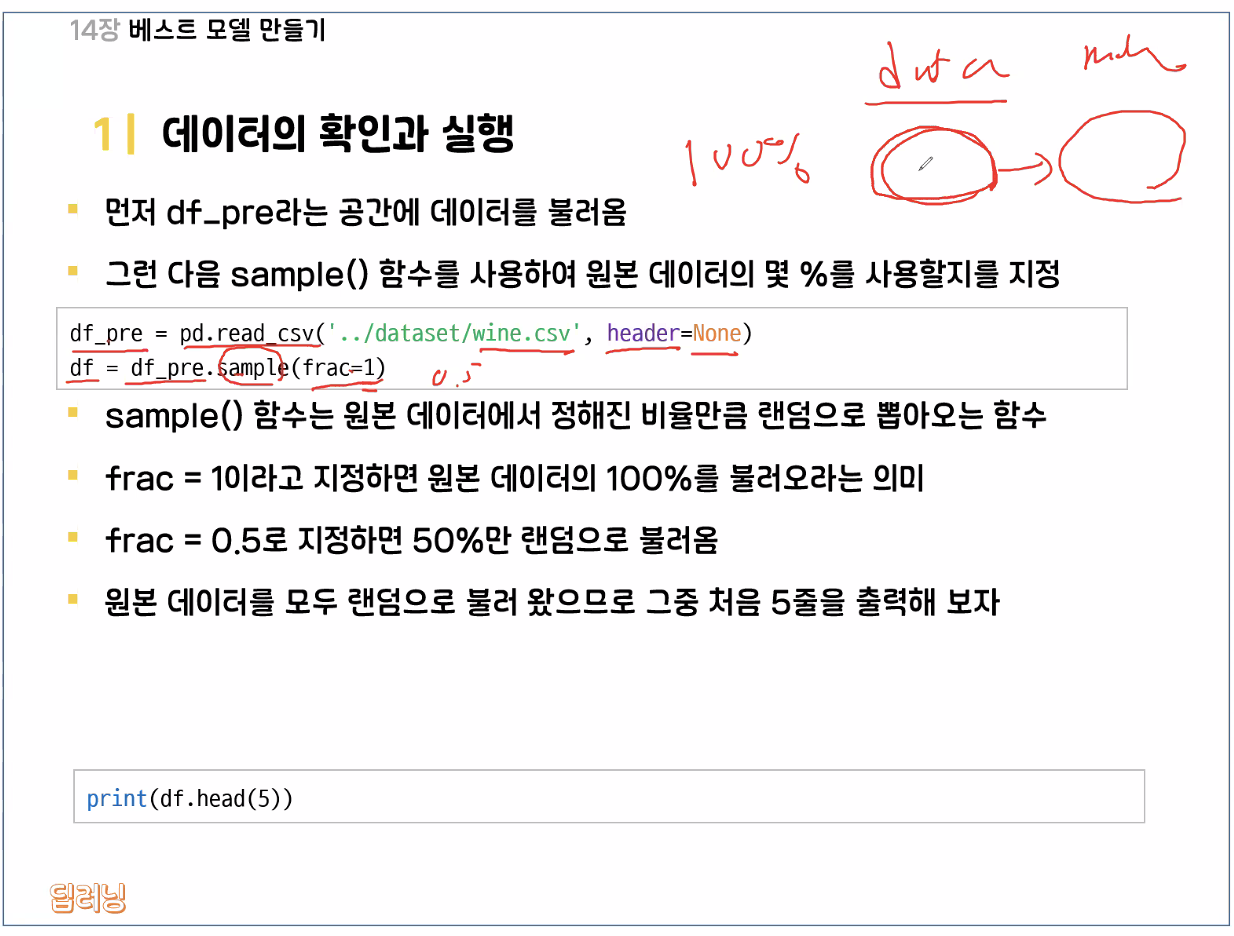

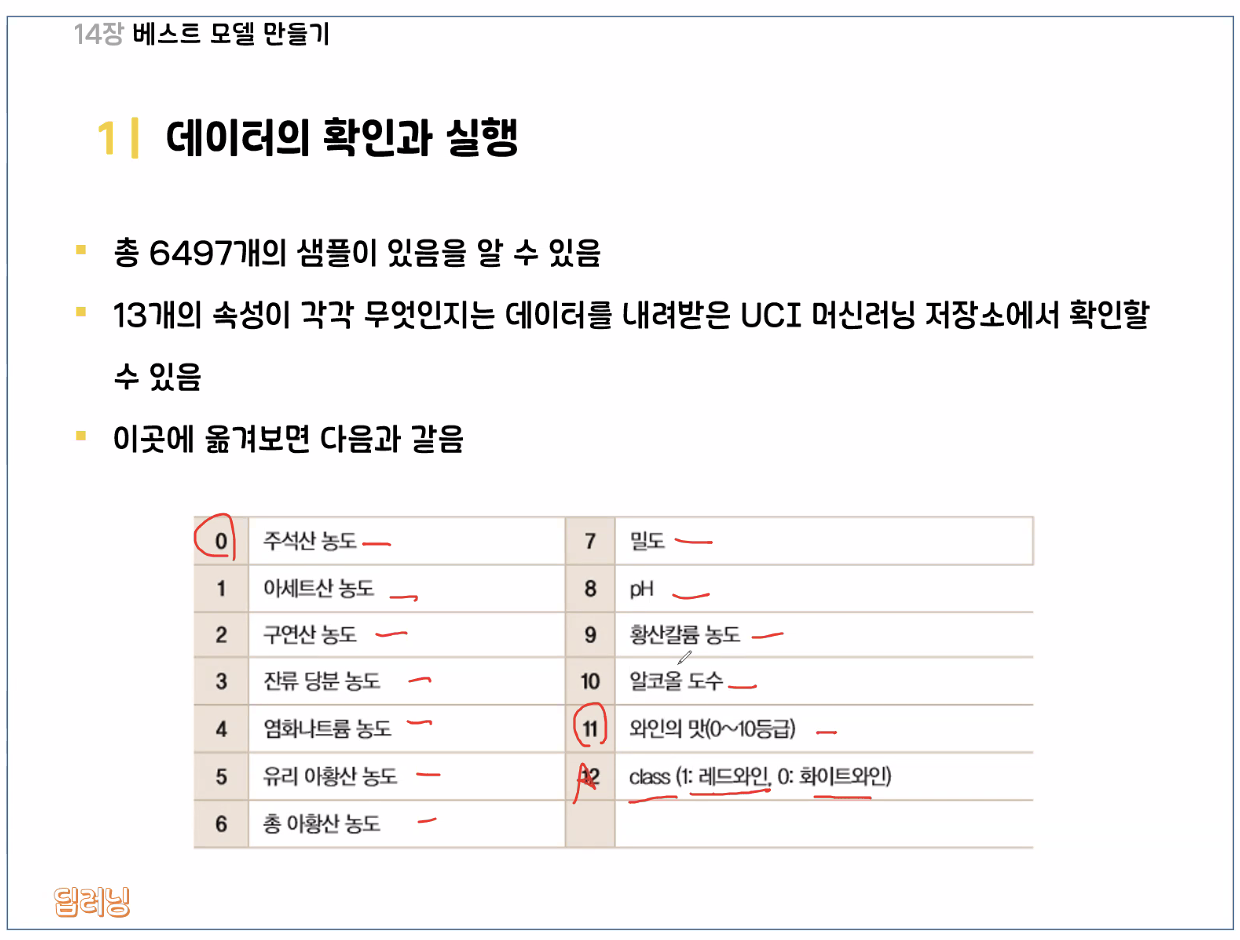

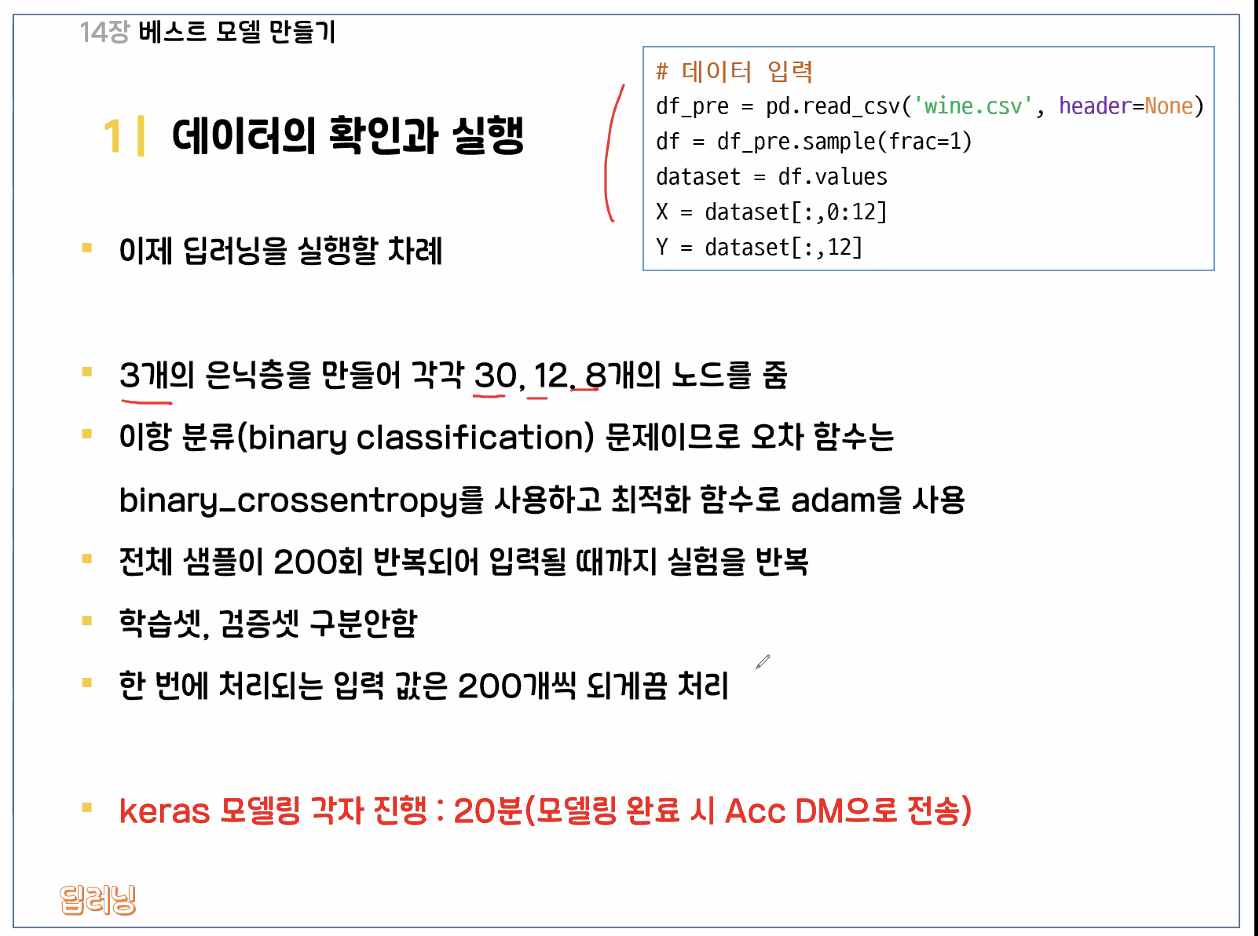

In [1]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 데이터 입력
df_pre = pd.read_csv('wine.csv', header=None)

# 데이터 섞기
df = df_pre.sample(frac=1)

# numpy 배열로 변환
dataset = df.values

# 입력값 / 정답값 분리
X = dataset[:, 0:12]
Y = dataset[:, 12]

# 모델 구성
model = Sequential()
model.add(Dense(30, input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 학습 과정 설정
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 모델 학습
model.fit(
    X,
    Y,
    epochs=200,
    batch_size=200,
    validation_split=0.2
)

Epoch 1/200


/opt/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7893 - loss: 0.3713 - val_accuracy: 0.8962 - val_loss: 0.3142
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9173 - loss: 0.2695 - val_accuracy: 0.9369 - val_loss: 0.2405
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9330 - loss: 0.2217 - val_accuracy: 0.9354 - val_loss: 0.2200
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9330 - loss: 0.2056 - val_accuracy: 0.9331 - val_loss: 0.2065
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9330 - loss: 0.1919 - val_accuracy: 0.9362 - val_loss: 0.1908
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9336 - loss: 0.1841 - val_accuracy: 0.9377 - val_loss: 0.1859
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9346 - loss: 0.1802 - val_accuracy: 0.9377 - val_loss: 0.1816
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9342 - loss: 0.1758 - val_accuracy: 0.9392 - val_loss: 0.1

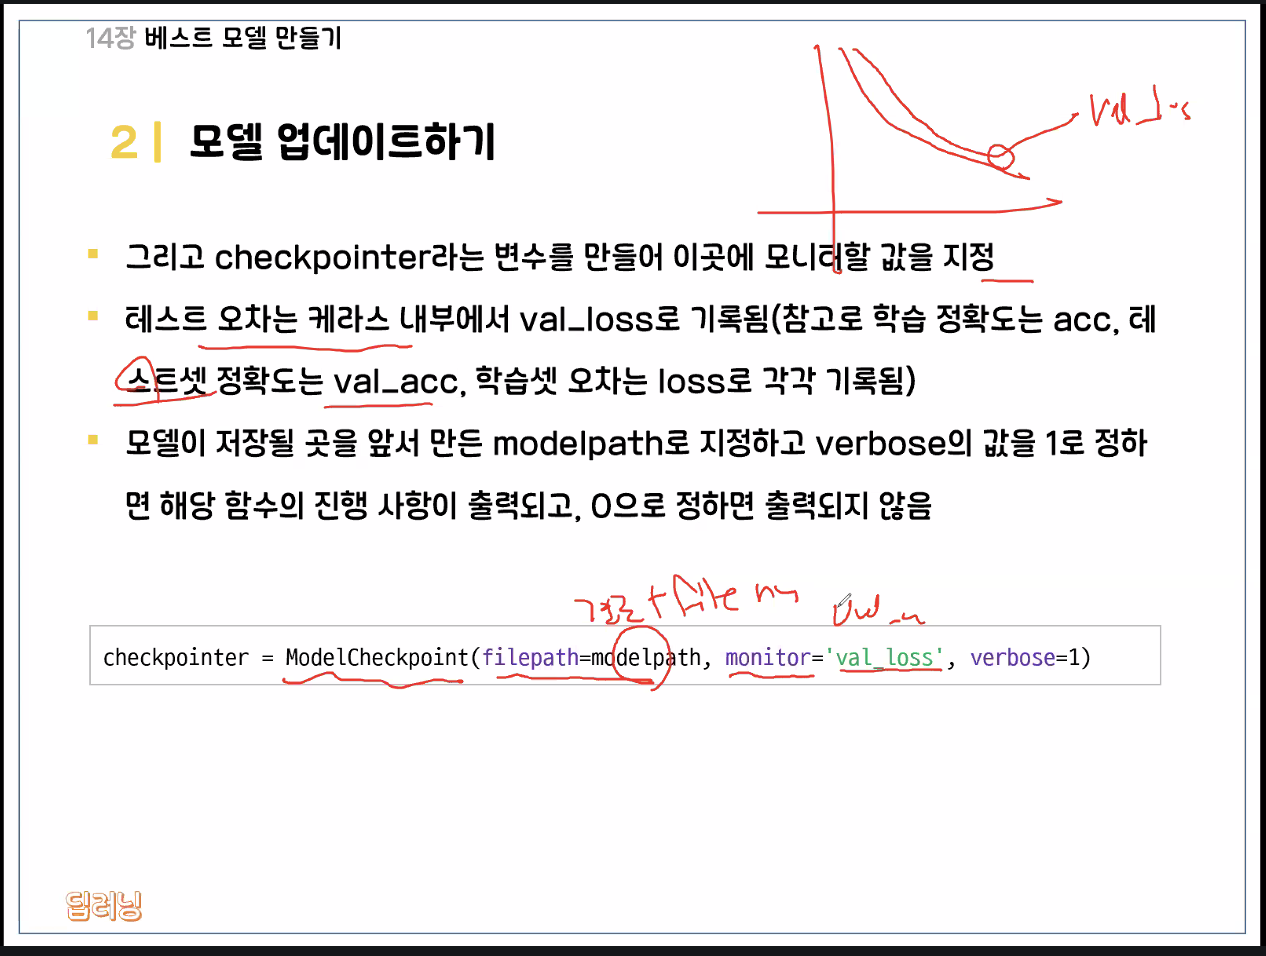

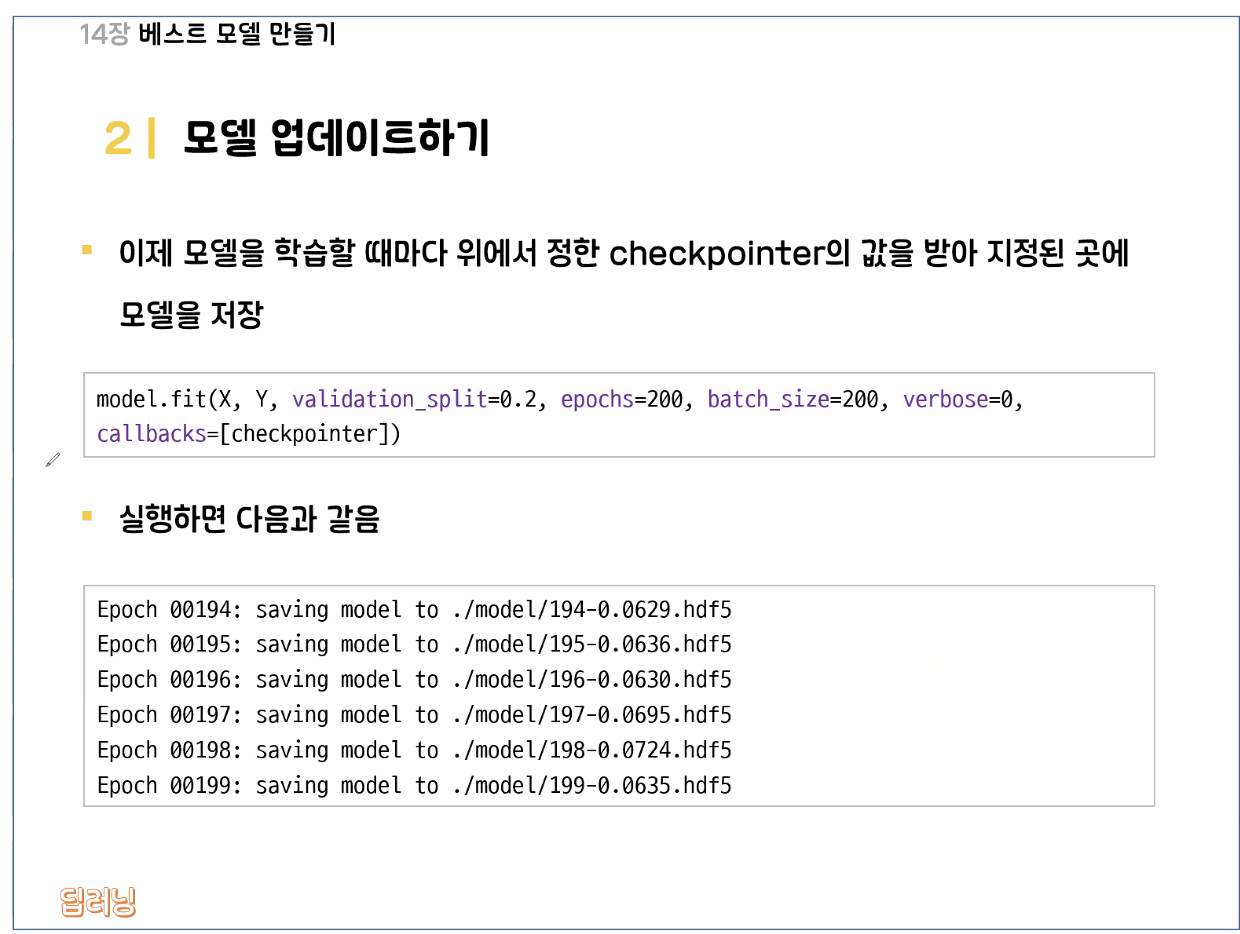

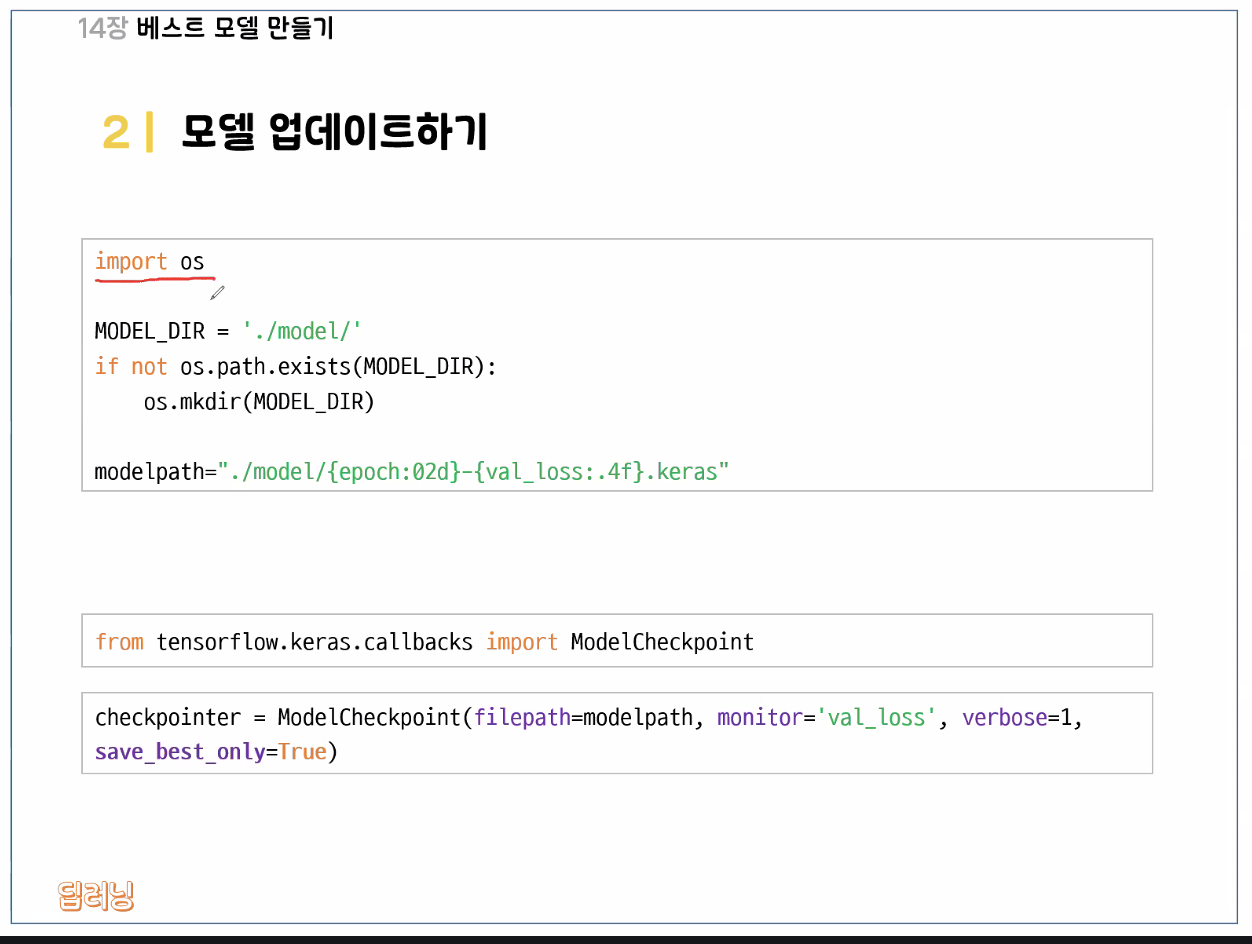

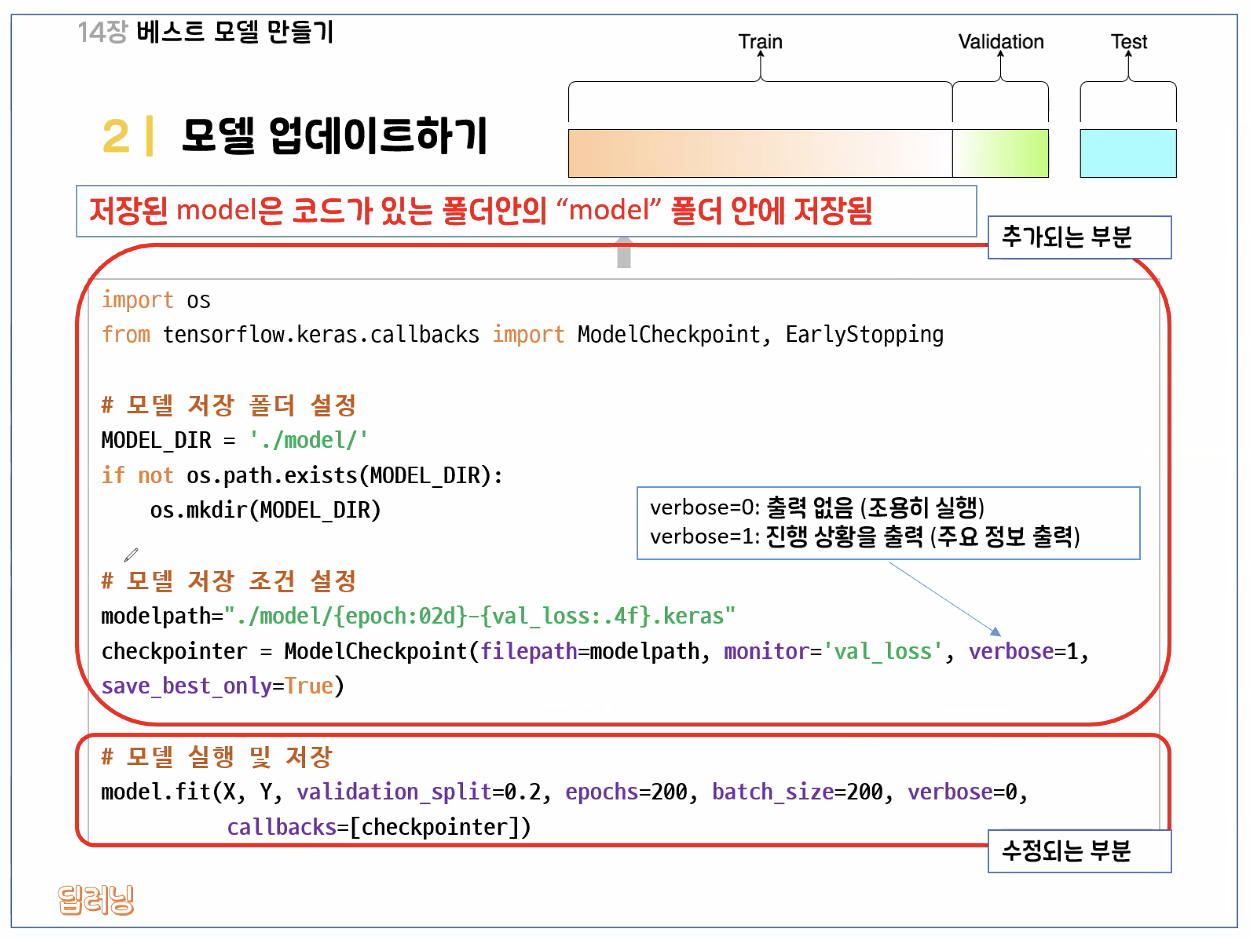

In [2]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 모델 저장 폴더 설정
MODEL_DIR = './model/'

if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

# 모델 저장 조건 설정
modelpath = "./model/{epoch:02d}-{val_loss:.4f}.keras"

checkpointer = ModelCheckpoint(
    filepath=modelpath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

# 모델 실행 및 저장
model.fit(
    X,
    Y,
    validation_split=0.2,
    epochs=200,
    batch_size=200,
    verbose=0,
    callbacks=[checkpointer]
)


Epoch 1: val_loss improved from None to 0.05617, saving model to ./model/01-0.0562.keras

Epoch 1: finished saving model to ./model/01-0.0562.keras

Epoch 2: val_loss improved from 0.05617 to 0.05297, saving model to ./model/02-0.0530.keras

Epoch 2: finished saving model to ./model/02-0.0530.keras

Epoch 3: val_loss did not improve from 0.05297

Epoch 4: val_loss improved from 0.05297 to 0.05030, saving model to ./model/04-0.0503.keras

Epoch 4: finished saving model to ./model/04-0.0503.keras

Epoch 5: val_loss did not improve from 0.05030

Epoch 6: val_loss did not improve from 0.05030

Epoch 7: val_loss did not improve from 0.05030

Epoch 8: val_loss did not improve from 0.05030

Epoch 9: val_loss improved from 0.05030 to 0.05013, saving model to ./model/09-0.0501.keras

Epoch 9: finished saving model to ./model/09-0.0501.keras

Epoch 10: val_loss did not improve from 0.05013

Epoch 11: val_loss did not improve from 0.05013

Epoch 12: val_loss did not improve from 0.05013

Epoch 1